In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###1. Load the ML-ready dataset

In [2]:
import pandas as pd

input_path = "/content/drive/MyDrive/student-risk-ml-project/data/processed/student_ml_ready.csv"

df = pd.read_csv(input_path)

print("Shape:", df.shape)
df.head()

Shape: (649, 44)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other,At_Risk
0,0,0,18,1,1,0,4,4,2,2,...,0,1,1,0,0,0,0,1,0,0
1,0,0,17,1,1,1,1,1,1,2,...,0,0,1,0,0,0,1,0,0,0
2,0,0,15,1,0,1,1,1,1,2,...,0,0,0,0,1,0,0,1,0,0
3,0,0,15,1,1,1,4,2,1,3,...,1,0,0,1,0,0,0,1,0,0
4,0,0,16,1,1,1,3,3,1,2,...,0,0,0,1,0,0,1,0,0,0


In [3]:
print("Missing values:", df.isnull().sum().sum())
print("Target counts:")
print(df["At_Risk"].value_counts())

Missing values: 0
Target counts:
At_Risk
0    549
1    100
Name: count, dtype: int64


###2. Split features and target

In [4]:
X = df.drop(columns=["At_Risk"])
y = df["At_Risk"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (649, 43)
y shape: (649,)


###3. Train/test split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (519, 43)
X_test: (130, 43)


###4. Scale the features

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###5. Train the Logistic Regression model

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

###6. Make predictions

In [8]:
y_pred = model.predict(X_test_scaled)

In [9]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

###7. Evaluate the model

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8461538461538461
Precision: 0.5
Recall   : 0.15
F1 Score : 0.23076923076923078


In [11]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       110
           1       0.50      0.15      0.23        20

    accuracy                           0.85       130
   macro avg       0.68      0.56      0.57       130
weighted avg       0.81      0.85      0.81       130



###8. Confusion matrix

In [12]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[107   3]
 [ 17   3]]


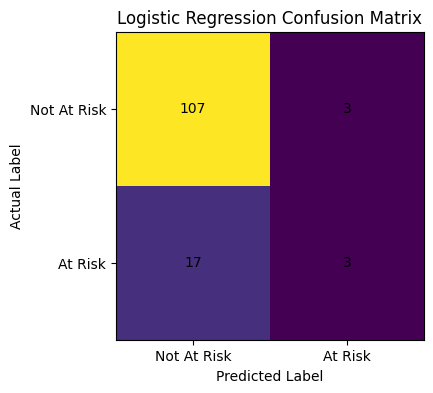

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.imshow(cm)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Not At Risk", "At Risk"])
plt.yticks([0, 1], ["Not At Risk", "At Risk"])

plt.show()

###10.ROC-AUC

In [14]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7686363636363638


###11. Save the results

In [15]:
logistic_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc]
})

logistic_results

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.846154,0.5,0.15,0.230769,0.768636


In [16]:
output_path = "/content/drive/MyDrive/student-risk-ml-project/data/processed/logistic_regression_results.csv"

logistic_results.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: /content/drive/MyDrive/student-risk-ml-project/data/processed/logistic_regression_results.csv


## ***Logistic Regression Summary***

Logistic Regression was trained as the first classification model for identifying At-Risk students.

The same 80/20 stratified train-test split was used to preserve target class proportions.

Because Logistic Regression is sensitive to feature scale, StandardScaler was fitted using only the training data and then applied to both training and test data.

The model was evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC

Special attention was given to Recall for the At-Risk class because false-negative predictions may result in genuinely at-risk students not receiving early support.